### 6. 학습 관련 기술들
---

### 6-1. 매개변수 갱신
###### 가중치와 bias 같은 매개변수의 최적값을 찾는 것을 최적화라고 한다. 매개변수의 기울기를 구해 매개변수 값을 갱신하는 방법을 확률적 경사 하강법(SGD)라고 한다.


In [1]:
# SGD를 이용한 업데이트 방법

class SGD:
    def __init__(self, lr = 0.01):
        self.lr = lr

    def update(self, params, grads):
        for key in params.keys():
            params[key] -= self.lr * grads[key]

- 이처럼 최적화를 담당하는 클래스를 분리해 구현하면 기능을 모듈화하기 좋다.

- *SGD 단점: 기울어진 방향이 최솟값과 다른 방향을 가리키면 지그재그로 탐색해서 비효율적이다.
---

#### 모멘텀

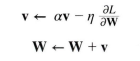

##### 모멘텀 업데이트 식에는 기존 경사하강법과 다르게 v가 추가되는데 이는 update 전의 방향과 이동량을 어느정도 유지시킨 상태에서 losff function의 기울기를 이용하여 v를 업데이트 한다는 의미이다.
- av 항은 물체가 아무런 힘을 받지 않을 때 서서히 하강시키는 역할을 한다. a는 보통 0.9로 설정한다.

In [ ]:
# Momentum

class Momentum:
    def __init__(self, lr = 0.01, momentum = 0.9):
        self.lr = lr
        self.momentum = momentum
        self.v = None

    def update(self, params, grads):
        if self.v is None:
            self.v = {}
            for key, val in params.items():
                self.v[key] = np.zeros_like(val) # v가 비어있으면 params에 있는 key,value를 복제한다 (value는 0으로)

        for key in params.keys():
            self.v[key] = self.momentum * self.v[key] - self.lr * grads[key]
            params[key] += self.v[key]

#196

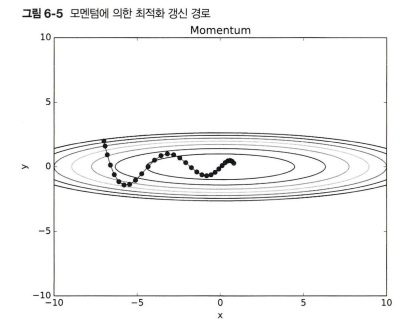
- SGD를 사용했을 때와 다르게 지그재그가 없는 것을 볼 수 있다.(av항이 속도를 유지시켜주기 때문에)